# `tools/preprocessing.py` smoke test

Loads one shot gather with `tools.segy_read.read_regular_shots` and exercises the four preprocessing primitives:

1. `add_noise` (Gaussian / Poisson, SNR-controlled)
2. `mask_traces` (uniform / random / continuous)
3. `spherical_divergence_correction`
4. `normalize` (`minmax` / `max_abs` / `mean_std`; `per = shot / trace / global`; optional abs-percentile clip)

All plots use the `seismic` colormap with a **percentile-based symmetric clip** (`vmin = -q_p(|x|)`, `vmax = +q_p(|x|)`, default `p=99`) so strong samples do not wash out the display.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from tools.segy_read import inspect_segy, read_regular_shots
from tools.preprocessing import (
    add_noise,
    mask_traces,
    spherical_divergence_correction,
    normalize,
)

rng = np.random.default_rng(0)

## Plot helper

`shot` has shape `(n_traces, n_time)`; we transpose to put time on the vertical axis (standard seismic display).
The symmetric clip uses `q = clip_pct` percentile of `|shot|` so a few large samples do not dominate the colorbar.

In [2]:
def plot_shot(ax, shot, title, clip_pct=99, force_symmetric=True):
    """Display a single shot gather (n_traces, n_time) with a seismic colormap."""
    vmax = float(np.quantile(np.abs(shot), clip_pct / 100.0))
    if vmax == 0:
        vmax = float(np.abs(shot).max() + 1e-8)
    if force_symmetric and shot.min() < -1e-6:
        vmin = -vmax
    else:
        vmin = float(shot.min())
    im = ax.imshow(
        shot.T, aspect='auto', cmap='seismic',
        vmin=vmin, vmax=vmax, interpolation='nearest',
    )
    ax.set_title(title)
    ax.set_xlabel('trace')
    ax.set_ylabel('time sample')
    return im


def plot_grid(shots_list, titles, ncols=None, figsize_per=(4.0, 3.5), clip_pct=99):
    n = len(shots_list)
    ncols = ncols or n
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
                             squeeze=False)
    for ax, shot, title in zip(axes.ravel(), shots_list, titles):
        im = plot_shot(ax, shot, title, clip_pct=clip_pct)
        fig.colorbar(im, ax=ax, shrink=0.8)
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 1. Load data with `tools.segy_read`

Uses the regular file `/data/liuqi/code/MAE/5d-transformer/data/SEGC3-45/SEG_45Shot_shots1-9.sgy`.  
`inspect_segy` gives per-FFID trace counts, from which we derive a safe `traces_per_shot`.  
We also read a downsampled copy (`time_downsample=2`) for sanity.

In [ ]:
SEGY_PATH = Path('/data/liuqi/code/MAE/5d-transformer/data/SEGC3-45/SEG_45Shot_shots1-9.sgy')
assert SEGY_PATH.exists(), f'SEG-Y file not found: {SEGY_PATH}'

info = inspect_segy(SEGY_PATH)
print('inspect_segy ->', info)

tmin, tmax = info['traces_per_ffid_min_max']
assert tmin == tmax, 'File looks irregular; use read_irregular_shots_by_header instead.'
traces_per_shot = tmin

shots, headers = read_regular_shots(
    SEGY_PATH,
    traces_per_shot=201,
    time_downsample=1,
    return_headers=True,
)
print('shots.shape     =', shots.shape, '| dtype =', shots.dtype)
print('headers keys    =', list(headers.keys()))
print('abs-amplitude (shot 0): min={:.3g}, max={:.3g}, q99={:.3g}'.format(
    np.abs(shots[0]).min(),
    np.abs(shots[0]).max(),
    np.quantile(np.abs(shots[0]), 0.99),
))

inspect_segy -> {'n_traces': 363609, 'n_samples': 625, 'sample_interval_us': 8000, 'unique_ffid_count': 9, 'traces_per_ffid_min_max': (40401, 40401)}


### Baseline visualization

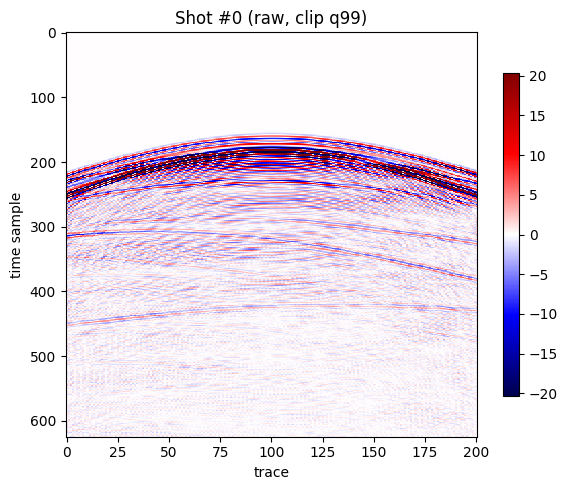

In [ ]:
SHOT_IDX = 0
shot = shots[SHOT_IDX]           # (n_traces, n_time)
plot_grid([shot], [f'Shot #{SHOT_IDX} (raw, clip q99)'], ncols=1, figsize_per=(6, 5))

## 2. `add_noise` — Gaussian and Poisson at controlled SNR

SNR definition: `SNR_dB = 10 * log10(var_signal / var_noise)` (per shot).
Lower dB = stronger noise.

gaussian: sigma[shot 0] = 2.33
poisson : scale[shot 0] = 9.31


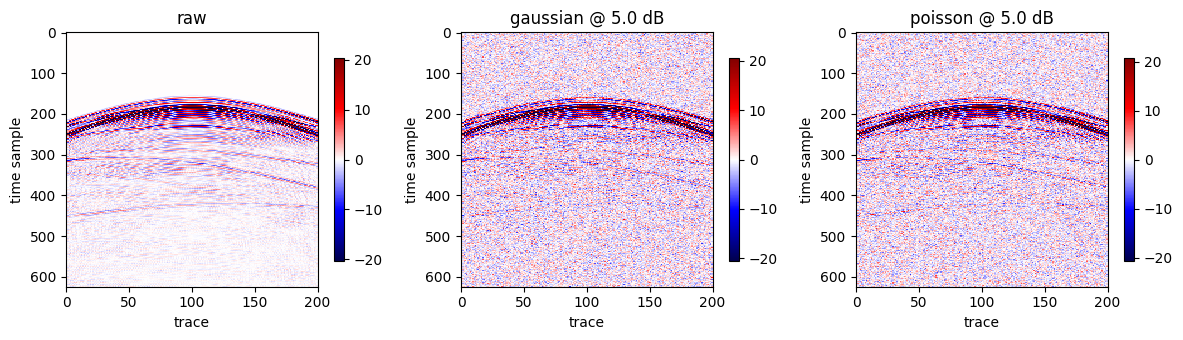

In [ ]:
snr_db = 5.0     # try 20 for light noise, 0 for heavy noise

noisy_g, info_g = add_noise(shots, kind='gaussian', snr_db=snr_db, rng=0)
noisy_p, info_p = add_noise(shots, kind='poisson',  snr_db=snr_db, rng=0)

print(f'gaussian: sigma[shot 0] = {info_g["sigma"][SHOT_IDX]:.3g}')
print(f'poisson : scale[shot 0] = {info_p["scale"][SHOT_IDX]:.3g}')

plot_grid(
    [shot, noisy_g[SHOT_IDX], noisy_p[SHOT_IDX]],
    [f'raw',
     f'gaussian @ {snr_db} dB',
     f'poisson @ {snr_db} dB'],
    ncols=3,
)

## 3. `mask_traces` — three missing patterns

- `"uniform"` keeps every `uniform_stride`-th trace and masks the rest (e.g. `uniform_stride=3` → keep indices `0, 3, 6, ...`; fallback from `ratio` is `max(2, round(1/(1-ratio)))`).
- `"random"` / `"continuous"` use `ratio` = fraction of missing traces per shot.
- Masked traces are filled with zero; the boolean mask has shape `(n_shots, n_traces)`, `True` = missing.

uniform  (stride=3): kept 67 / 201 traces -> missing per shot = [134 134 134 ... 134 134 134]
random   (ratio=0.3): missing per shot = [60 60 60 ... 60 60 60]
continuous (ratio=0.3): missing per shot = [60 60 60 ... 60 60 60]


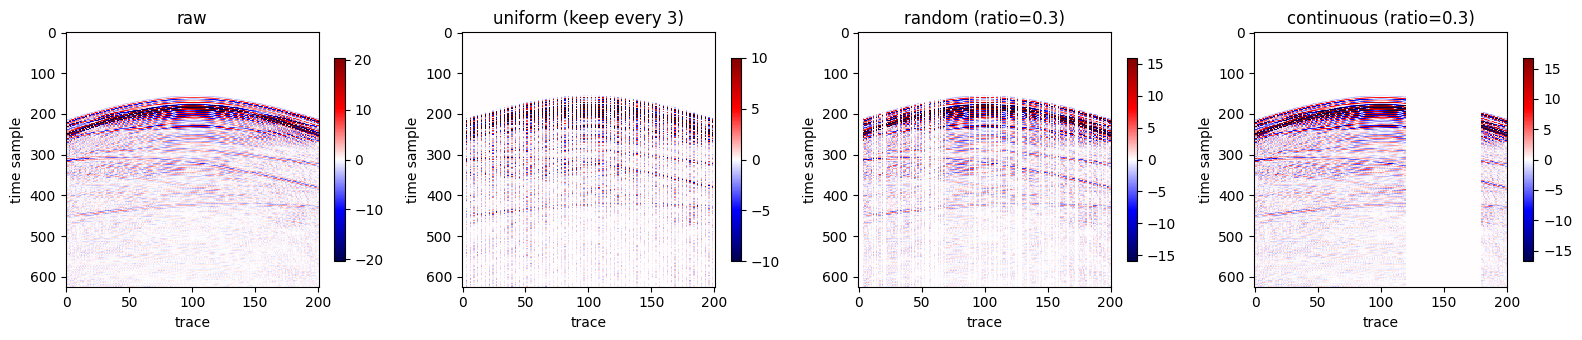

In [ ]:
ratio = 0.3
stride = 3  # uniform mode: keep every 3rd trace (0, 3, 6, ...)

masked_u, mk_u = mask_traces(shots, mode='uniform',    uniform_stride=stride)
masked_r, mk_r = mask_traces(shots, mode='random',     ratio=ratio, rng=0)
masked_c, mk_c = mask_traces(shots, mode='continuous', ratio=ratio, rng=0)

n_traces = shots.shape[1]
print(f'uniform  (stride={stride}): kept {n_traces // stride + (n_traces % stride > 0)} / {n_traces} traces -> '
      f'missing per shot = {mk_u.sum(axis=1)}')
print(f'random   (ratio={ratio}): missing per shot = {mk_r.sum(axis=1)}')
print(f'continuous (ratio={ratio}): missing per shot = {mk_c.sum(axis=1)}')

plot_grid(
    [shot, masked_u[SHOT_IDX], masked_r[SHOT_IDX], masked_c[SHOT_IDX]],
    ['raw',
     f'uniform (keep every {stride})',
     f'random (ratio={ratio})',
     f'continuous (ratio={ratio})'],
    ncols=4,
)

## 4. `spherical_divergence_correction` — `x *= (t + t0) ** power`

`power = 2.0` is the classic uniform-earth geometric-spreading gain.  
The plot compares raw vs. gained; the deep part is amplified, as expected.

sample interval dt = 0.008000 s


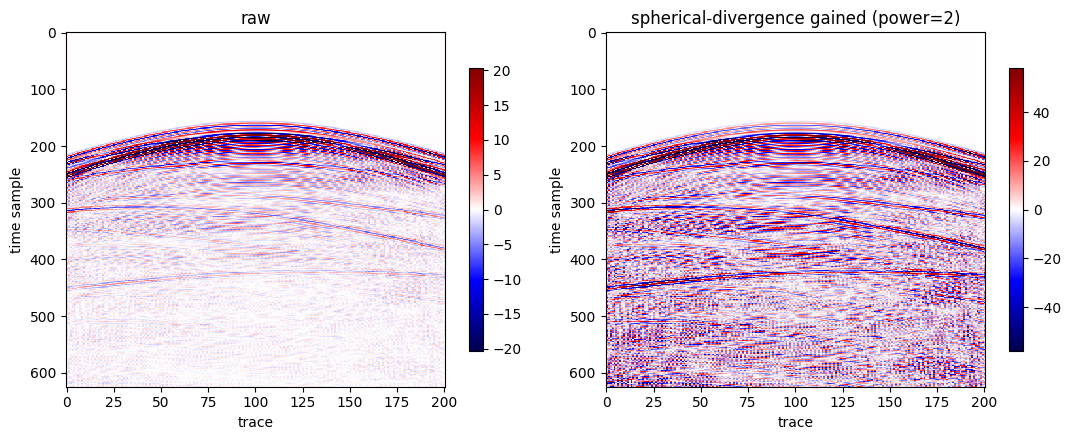

In [ ]:
dt = float(info['sample_interval_us']) * 1e-6   # microseconds -> seconds
print(f'sample interval dt = {dt:.6f} s')

gained = spherical_divergence_correction(shots, dt=dt, power=2.0)

plot_grid(
    [shot, gained[SHOT_IDX]],
    ['raw', 'spherical-divergence gained (power=2)'],
    ncols=2,
    figsize_per=(5.5, 4.5),
)

## 5. `normalize` — modes and scopes

### How the `per` argument maps to reduction axes for a 3D input `(N, C, T)`

| `per`      | reduce axes | stat shape (`keepdims=True`) | meaning                                      |
| ---------- | ----------- | ---------------------------- | -------------------------------------------- |
| `"shot"`   | `(-2, -1)`  | `(N, 1, 1)`                  | one statistic per shot                       |
| `"trace"`  | `(-1,)`     | `(N, C, 1)`                  | one statistic per `(shot, trace)`            |
| `"global"` | `(0, 1, 2)` | `(1, 1, 1)`                  | one statistic for the whole tensor           |

When `clip_percentile` is set, the same reduction axes are used to compute
`quantile(|x|, p)`, clipping is applied **before** the normalization stats.

### 5a. Three modes at `per="shot"`, no clip

minmax   shot 0: min=0, max=1  (stats min=-50.5, max=51)
max_abs  shot 0: |x|.max=1  (stats max_abs=51)
mean_std shot 0: mean=1.04e-10, std=1  (stats mean=6.27e-06, std=4.14)


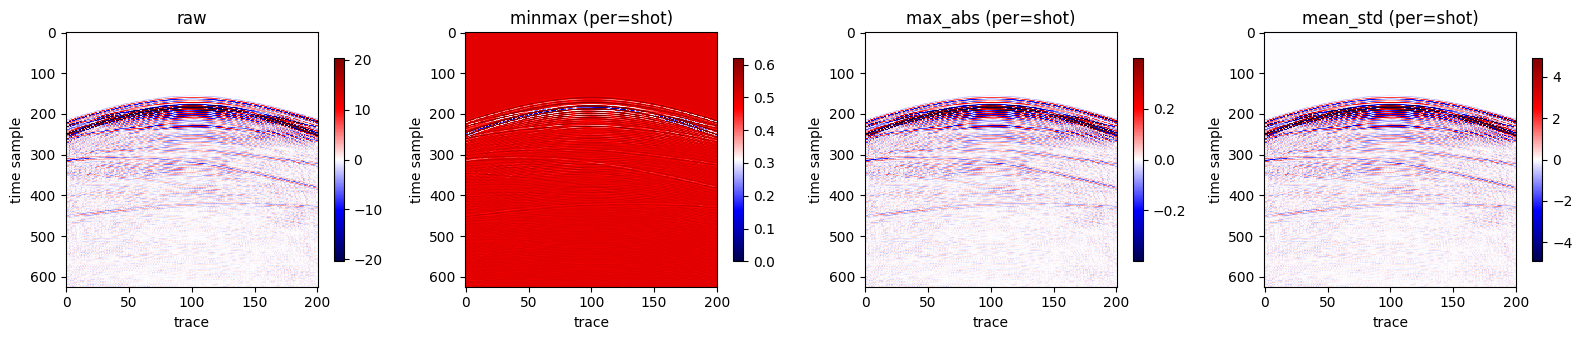

In [ ]:
n_mm, s_mm = normalize(shots, mode='minmax',   per='shot')
n_ma, s_ma = normalize(shots, mode='max_abs',  per='shot')
n_ms, s_ms = normalize(shots, mode='mean_std', per='shot')

print(f'minmax   shot 0: min={n_mm[SHOT_IDX].min():.3g}, max={n_mm[SHOT_IDX].max():.3g}  '
      f'(stats min={s_mm["min"][SHOT_IDX]:.3g}, max={s_mm["max"][SHOT_IDX]:.3g})')
print(f'max_abs  shot 0: |x|.max={np.abs(n_ma[SHOT_IDX]).max():.3g}  '
      f'(stats max_abs={s_ma["max_abs"][SHOT_IDX]:.3g})')
print(f'mean_std shot 0: mean={n_ms[SHOT_IDX].mean():.3g}, std={n_ms[SHOT_IDX].std():.3g}  '
      f'(stats mean={s_ms["mean"][SHOT_IDX]:.3g}, std={s_ms["std"][SHOT_IDX]:.3g})')

plot_grid(
    [shot, n_mm[SHOT_IDX], n_ma[SHOT_IDX], n_ms[SHOT_IDX]],
    ['raw', 'minmax (per=shot)', 'max_abs (per=shot)', 'mean_std (per=shot)'],
    ncols=4,
)

### 5b. Same mode (`max_abs`), three scopes

Visualizing how the scope of the reducer reshapes the output:
`per='shot'` keeps trace-to-trace amplitude contrasts within a shot; `per='trace'`
scales each trace independently (kills inter-trace amplitudes); `per='global'`
applies a single scaling to the whole dataset.

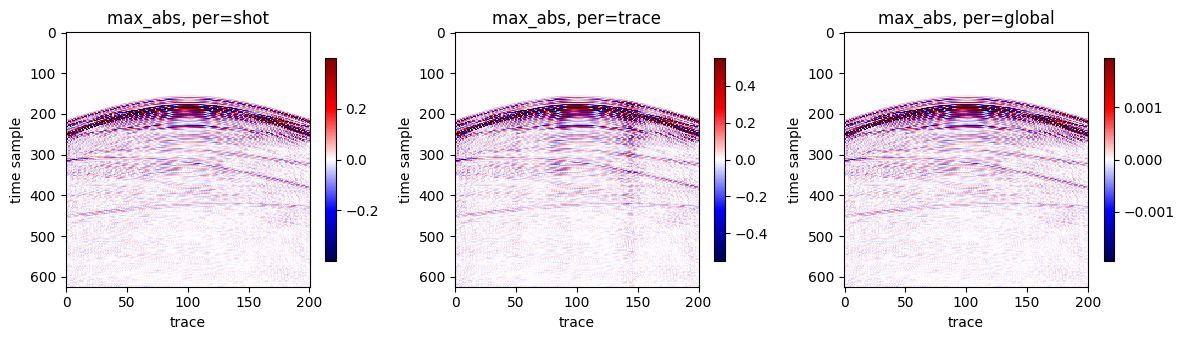

In [ ]:
n_shot,   _ = normalize(shots, mode='max_abs', per='shot')
n_trace,  _ = normalize(shots, mode='max_abs', per='trace')
n_global, _ = normalize(shots, mode='max_abs', per='global')

plot_grid(
    [n_shot[SHOT_IDX], n_trace[SHOT_IDX], n_global[SHOT_IDX]],
    ['max_abs, per=shot', 'max_abs, per=trace', 'max_abs, per=global'],
    ncols=3,
)

### 5c. `clip_percentile` effect (`max_abs`, `per='shot'`)

`clip_percentile=99` clips to `+/- q99(|x|)` **before** the `max_abs` reducer
sees the data, so the remaining samples use most of the `[-1, 1]` range instead
of being crushed by a handful of outliers.

no clip : |x|.max(shot 0) = 1 (per-shot ratio: 51)
clip 99 : |x|.max(shot 0) = 1 (thresh 20.4, ratio 20.4)


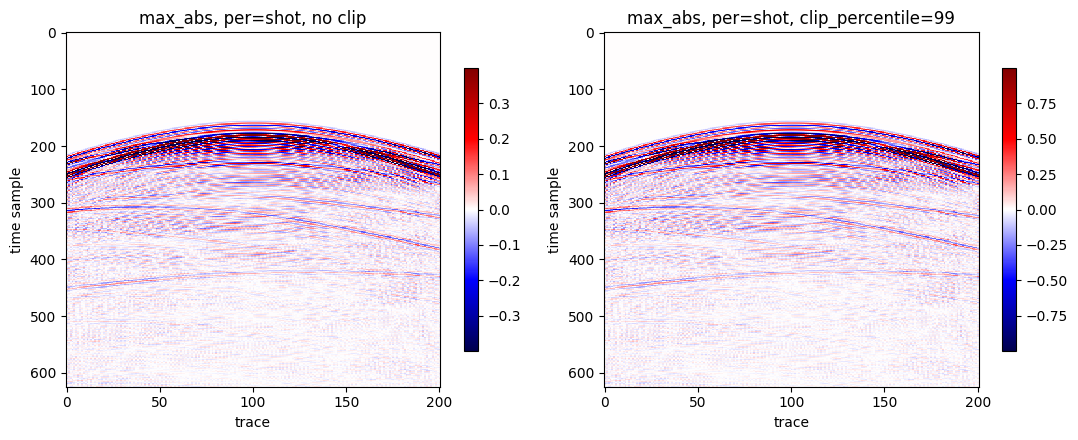

In [ ]:
no_clip, st_no = normalize(shots, mode='max_abs', per='shot', clip_percentile=None)
clip99,  st_c  = normalize(shots, mode='max_abs', per='shot', clip_percentile=99.0)

print(f'no clip : |x|.max(shot 0) = {np.abs(no_clip[SHOT_IDX]).max():.3g} (per-shot ratio: '
      f'{float(st_no["max_abs"][SHOT_IDX]):.3g})')
print(f'clip 99 : |x|.max(shot 0) = {np.abs(clip99[SHOT_IDX]).max():.3g} '
      f'(thresh {float(st_c["clip_threshold"][SHOT_IDX]):.3g}, '
      f'ratio {float(st_c["max_abs"][SHOT_IDX]):.3g})')

plot_grid(
    [no_clip[SHOT_IDX], clip99[SHOT_IDX]],
    ['max_abs, per=shot, no clip', 'max_abs, per=shot, clip_percentile=99'],
    ncols=2,
    figsize_per=(5.5, 4.5),
)

## 6. `normalize(override_stats=...)` — apply caller-supplied statistics

`override_stats` forces `per="global"`, forbids `clip_percentile`, and bypasses on-the-fly reduction. We verify that:

1. Passing the stats a fresh `normalize(..., per="global")` call returns reproduces the same output.
2. Mismatched `per` or setting `clip_percentile` raises `ValueError`.
3. Missing keys raise `ValueError`.

In [ ]:
ref, st_ref = normalize(shots, mode='mean_std', per='global')

override = {'mean': float(st_ref['mean']), 'std': float(st_ref['std'])}
out, st_out = normalize(shots, mode='mean_std', per='global', override_stats=override)

print(f"max |out - ref| = {np.abs(out - ref).max():.3e}")
assert np.allclose(out, ref, atol=1e-6), 'override_stats must replay the same transform'
assert st_out['mean'] == override['mean']
assert st_out['std']  == override['std']

# Minmax round-trip with hard-coded physical bounds.
phys = {'min': float(shots.min()), 'max': float(shots.max())}
out_mm, _ = normalize(shots, mode='minmax', per='global', override_stats=phys)
print(f"minmax(override) in [{out_mm.min():.3f}, {out_mm.max():.3f}]")
assert 0.0 <= out_mm.min() and out_mm.max() <= 1.0

# Error paths.
for kwargs, why in [
    (dict(mode='mean_std', per='shot',   override_stats=override),          "per != 'global'"),
    (dict(mode='mean_std', per='global', override_stats=override, clip_percentile=99.0), 'clip_percentile'),
    (dict(mode='mean_std', per='global', override_stats={'mean': 0.0}),     'missing key'),
]:
    try:
        normalize(shots, **kwargs)
    except ValueError as exc:
        print(f"[ok] {why}: {exc}")
    else:
        raise AssertionError(f'expected ValueError for: {why}')

max |out - ref| = 0.000e+00
minmax(override) in [0.000, 1.000]
[ok] per != 'global': override_stats requires per='global' (the supplied scalars are applied uniformly to the whole array); got per='shot'.
[ok] clip_percentile: override_stats and clip_percentile are mutually exclusive: user-supplied stats are authoritative; clip the input yourself before calling normalize() if needed.
[ok] missing key: override_stats is missing required keys for mode='mean_std': ['std']. Expected: ['mean', 'std'].


## 7. `patchify_uniform` + `unpatchify_uniform` — full coverage + round-trip

Slice one shot with overlap, then reconstruct. Checks:

- Last patch on each axis is tail-anchored (`last_start == length - patch`).
- `unpatchify_uniform(patchify_uniform(x)) == x` within float tolerance (averages overlapping regions).
- Works with both `output_ndim=3` and `output_ndim=4`.

2D input (201, 625) -> patches (28, 64, 128)  (starts t=[  0  48  96 137], w=[  0  96 192 288 384 480 497])
recon.shape = (201, 625),  max |recon - orig| = 5.960e-08
3D input (1809, 201, 625) -> patches4 (50652, 1, 64, 128)  (n_per_shot=28)
recon3d.shape = (1809, 201, 625),  max |recon3d - shots| = 9.537e-07


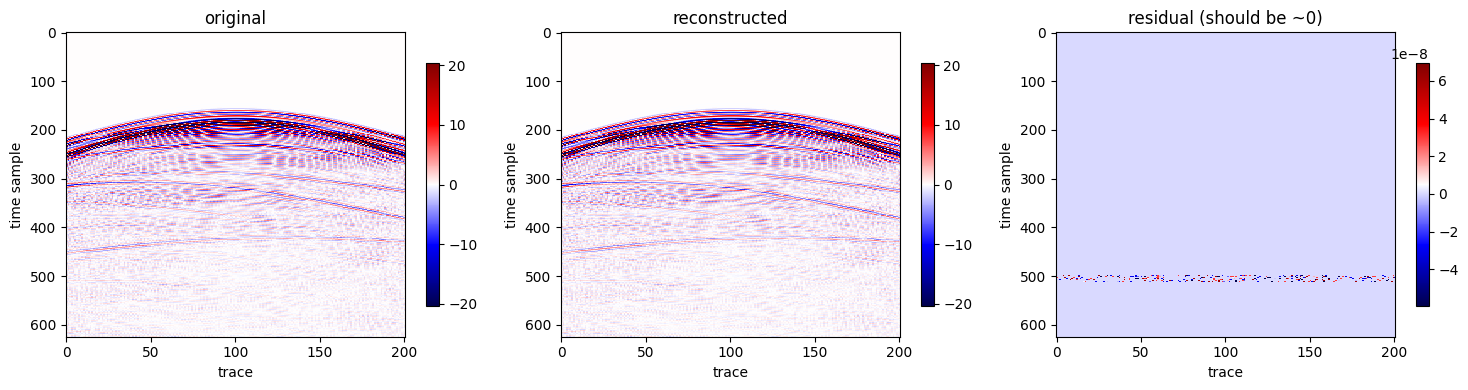

In [ ]:
from tools.patching import patchify_uniform, patchify_random, unpatchify_uniform

single = shots[SHOT_IDX]                # 2D input (n_traces, n_time)
patch_size = (64, 128)
overlap = 0.25

patches, info = patchify_uniform(single, patch_size=patch_size, overlap=overlap, output_ndim=3)
print(f"2D input {single.shape} -> patches {patches.shape}  (starts t={info['trace_starts']}, w={info['time_starts']})")

assert int(info['trace_starts'][-1]) == single.shape[0] - patch_size[0], 'last trace start must be tail-anchored'
assert int(info['time_starts'][-1])  == single.shape[1] - patch_size[1], 'last time start must be tail-anchored'

recon = unpatchify_uniform(patches, info)
print(f"recon.shape = {recon.shape},  max |recon - orig| = {np.abs(recon - single).max():.3e}")
assert recon.shape == single.shape and np.allclose(recon, single, atol=1e-6)

# 3D + output_ndim=4 round-trip.
patches4, info4 = patchify_uniform(shots, patch_size=patch_size, overlap=overlap, output_ndim=4)
print(f"3D input {shots.shape} -> patches4 {patches4.shape}  (n_per_shot={info4['n_per_shot']})")
assert patches4.shape[1] == 1

recon3d = unpatchify_uniform(patches4, info4)
print(f"recon3d.shape = {recon3d.shape},  max |recon3d - shots| = {np.abs(recon3d - shots).max():.3e}")
assert recon3d.shape == shots.shape and np.allclose(recon3d, shots, atol=1e-6)

plot_grid(
    [single, recon, recon - single],
    ['original', 'reconstructed', 'residual (should be ~0)'],
    ncols=3,
    figsize_per=(5.0, 4.0),
)

## 8. `patchify_random` — per-shot sampling, reproducibility

`n_patches` is **per shot**, so the total output count is `n_shots * n_patches`.
Reproducibility is checked by passing the same integer seed twice, and non-invertibility by verifying `unpatchify_uniform` rejects the random `info`.

random patches shape = (10854, 64, 128) (expect (10854, 64, 128))
[ok] random info rejected by unpatchify_uniform: unpatchify_uniform expects info['mode']=='uniform', got 'random'. Random patching is non-invertible.


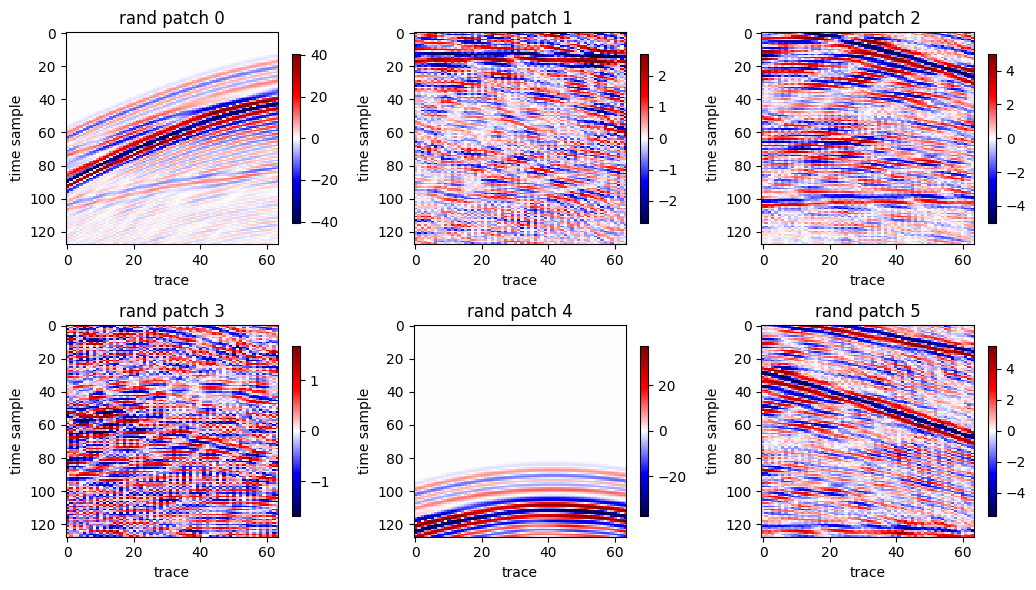

In [ ]:
n_per_shot = 6
rng_patches1, info_r1 = patchify_random(shots, patch_size=(64, 128), n_patches=n_per_shot, output_ndim=3, rng=42)
rng_patches2, info_r2 = patchify_random(shots, patch_size=(64, 128), n_patches=n_per_shot, output_ndim=3, rng=42)

n_shots = shots.shape[0]
print(f"random patches shape = {rng_patches1.shape} (expect ({n_shots * n_per_shot}, 64, 128))")
assert rng_patches1.shape == (n_shots * n_per_shot, 64, 128)
assert np.array_equal(rng_patches1, rng_patches2), 'same seed must reproduce the same patches'
assert info_r1['trace_starts'].shape == (n_shots, n_per_shot)
assert info_r1['time_starts'].shape == (n_shots, n_per_shot)

try:
    unpatchify_uniform(rng_patches1, info_r1)
except ValueError as exc:
    print(f"[ok] random info rejected by unpatchify_uniform: {exc}")
else:
    raise AssertionError('random info must not be invertible')

# Visualize a few random patches from shot 0.
show = rng_patches1[:min(6, n_per_shot)]
plot_grid(
    list(show),
    [f"rand patch {i}" for i in range(len(show))],
    ncols=3,
    figsize_per=(3.5, 3.0),
)

## 9. `utils.metrics` — MSE / RMSE / MAE / SNR / PSNR / SSIM

Uses the Section 7 patches (`(n_shots * n_per_shot, 1, 64, 128)`) as the target so SSIM's 2D convolution stays cheap. The prediction is `target + 5% · data_range · N(0, 1)`. Checks:

- Identity (`pred = target`): MSE = RMSE = MAE = 0; SSIM = 1.
- `rmse` / `snr` / `psnr` accept `reduction='per_sample'` (default; mean of per-sample scores) or `reduction='global'`. Only the global reduction preserves the textbook identities `RMSE == sqrt(MSE)` and `PSNR == 10·log10(data_range² / MSE)` exactly; the cell prints both reductions side by side and verifies the identity holds for `reduction='global'` (up to fp32 rounding).
- SSIM accepts both `(B, C, H, W)` and `(B, H, W)`, and raises if spatial sides are smaller than the window.

In [ ]:
import math
import torch

from utils.metrics import (
    METRIC_REGISTRY, build_metrics, compute_metrics,
    MSE, RMSE, MAE, SNR, PSNR, SSIM,
)

print('registered metrics:', sorted(METRIC_REGISTRY))

# Use patches (64, 128) as the target so SSIM's 2D convolution stays cheap.
# patches_4d shape: (n_shots * n_per_shot, 1, 64, 128).
patches_4d, _ = patchify_uniform(shots, patch_size=(64, 128), overlap=0.0, output_ndim=4)
target = torch.from_numpy(patches_4d.copy()).float()
print('target shape:', tuple(target.shape))

data_range = float(target.max() - target.min())
rng = torch.Generator().manual_seed(0)
noise = 0.05 * data_range * torch.randn(target.shape, generator=rng)
pred = target + noise

# Default reductions: rmse / snr / psnr are 'per_sample' (mean of per-sample scores).
metrics = build_metrics([
    {'name': 'mse'},
    {'name': 'rmse'},
    {'name': 'mae'},
    {'name': 'snr'},
    {'name': 'psnr', 'params': {'data_range': data_range}},
    {'name': 'ssim', 'params': {'data_range': data_range, 'window_size': 11}},
])
scores = compute_metrics(metrics, pred, target)
print(f'noisy pred (sigma = 0.05 * range = {0.05 * data_range:.3g}), per_sample defaults:')
for name, value in scores.items():
    print(f"  {name:5s} = {value:.6f}")

# Side-by-side comparison: per_sample vs global on the SAME (pred, target).
rmse_ps = RMSE(reduction='per_sample')(pred, target)
rmse_gl = RMSE(reduction='global')(pred, target)
snr_ps  = SNR(reduction='per_sample')(pred, target)
snr_gl  = SNR(reduction='global')(pred, target)
psnr_ps = PSNR(data_range=data_range, reduction='per_sample')(pred, target)
psnr_gl = PSNR(data_range=data_range, reduction='global')(pred, target)
print('reduction comparison (per_sample vs global):')
print(f"  RMSE  -> {rmse_ps:.6f} vs {rmse_gl:.6f}")
print(f"  SNR   -> {snr_ps:.6f} vs {snr_gl:.6f}")
print(f"  PSNR  -> {psnr_ps:.6f} vs {psnr_gl:.6f}")

# Identity: pred == target -> trivially perfect under either reduction.
id_scores = {
    'mse':  MSE()(target, target),
    'rmse_ps': RMSE(reduction='per_sample')(target, target),
    'rmse_gl': RMSE(reduction='global')(target, target),
    'mae':  MAE()(target, target),
    'ssim': SSIM(data_range=data_range)(target, target),
}
print('identity (pred == target):', {k: round(v, 6) for k, v in id_scores.items()})
assert id_scores['mse']  == 0.0
assert id_scores['rmse_ps'] == 0.0
assert id_scores['rmse_gl'] == 0.0
assert id_scores['mae']  == 0.0
assert abs(id_scores['ssim'] - 1.0) < 1e-6

# Textbook identities only hold under reduction='global'.
mse_val = scores['mse']
psnr_manual = 10.0 * math.log10(data_range ** 2 / mse_val)
print(f"sqrt(mse) vs RMSE(global)  -> {math.sqrt(mse_val):.6f} vs {rmse_gl:.6f}")
print(f"PSNR(global) vs manual     -> {psnr_gl:.6f} vs {psnr_manual:.6f}")
assert abs(math.sqrt(mse_val) - rmse_gl) < 1e-3       # exact up to fp32 rounding
assert abs(psnr_gl - psnr_manual) < 1e-4              # PSNR(global) is a closed-form of MSE

# Reduction validation.
try:
    SNR(reduction='median')
except ValueError as exc:
    print(f"[ok] bad reduction rejected: {exc}")

# Error paths.
try:
    SSIM(window_size=11)(torch.zeros(1, 1, 8, 8), torch.zeros(1, 1, 8, 8))
except ValueError as exc:
    print(f"[ok] tiny-spatial rejected: {exc}")

try:
    MSE()(torch.zeros(2, 3), torch.zeros(2, 4))
except ValueError as exc:
    print(f"[ok] shape mismatch rejected: {exc}")

registered metrics: ['mae', 'mse', 'psnr', 'rmse', 'snr', 'ssim']
target shape: (36180, 1, 64, 128)
noisy pred (sigma = 0.05 * range = 823), per_sample defaults:
  mse   = 676598.937500
  rmse  = 822.531128
  mae   = 656.294617
  snr   = -57.015633
  psnr  = 26.021196
  ssim  = 0.190956
reduction comparison (per_sample vs global):
  RMSE  -> 822.531128 vs 822.556335
  SNR   -> -57.015633 vs -40.191196
  PSNR  -> 26.021196 vs 26.020662
identity (pred == target): {'mse': 0.0, 'rmse_ps': 0.0, 'rmse_gl': 0.0, 'mae': 0.0, 'ssim': 1.0}
sqrt(mse) vs RMSE(global)  -> 822.556343 vs 822.556335
PSNR(global) vs manual     -> 26.020662 vs 26.020663
[ok] bad reduction rejected: SNR: reduction must be one of ('global', 'per_sample'), got 'median'.
[ok] tiny-spatial rejected: SSIM: spatial size (8, 8) smaller than window_size 11.
[ok] shape mismatch rejected: MSE: pred shape (2, 3) != target shape (2, 4).


## 10. `utils.visualization` & `utils.logger`

- `plot_sample`: 4 panels (`input | prediction | target | residual`) when `target` is given; falls back to 2 panels when not. Auto-squeezes `(B, C, H, W)` / `(B, H, W)` to a single 2D map.
- `plot_loss_curve` / `plot_metrics_curve`: one line per series; auto log-Y for losses spanning > 2 decades; all-NaN series are dropped silently.
- `visualize_random_sample(model, loader, ..., seed=None)`: draws a random index from `loader.dataset`, runs the model under `eval() + no_grad`, and forwards `(input, prediction, target)` to `plot_sample`. `seed=None` -> different sample each call (what `scripts/train.py` uses); pin `seed=42` to lock the same one for A/B comparisons.
- `TrainingLogger`: writes `train_log.txt` (timestamped, also to stdout) plus append-only `loss_history.csv` (`epoch, lr, *loss_keys`) and `metrics_history.csv` (`epoch, *metric_keys`). It also auto-refreshes `loss_curve.png` / `metrics_curve.png` every `plot_interval` epochs (default 5; the cell below uses 2 for visibility), and re-draws once on `close()`. Resumed runs rehydrate the in-memory history from the existing CSVs so curves stay continuous across restarts.

In [ ]:
import tempfile, csv as _csv
from pathlib import Path as _Path

import torch.nn as _nn
from torch.utils.data import Dataset as _Dataset, DataLoader as _DataLoader

from utils import (
    plot_sample, plot_loss_curve, plot_metrics_curve,
    visualize_random_sample, TrainingLogger,
)

tmp_root = _Path(tempfile.mkdtemp(prefix='benchmark_viz_log_'))
print('scratch dir:', tmp_root)

# --- plot_sample with and without target --------------------------------------
# Reuse Section 9 patches: target = clean, pred = target + noise. Use
# (target + pred) / 2 as a fake "partially denoised" prediction so the
# residual panel carries a non-trivial signature instead of all-zero.
vis_input = pred[:1]
vis_target = target[:1]
vis_pred = 0.5 * (vis_input + vis_target)
fig_full = plot_sample(vis_input, vis_pred, vis_target,
                       save_path=tmp_root / 'plot_sample_full.png',
                       title='plot_sample (4 panels)')
fig_minimal = plot_sample(vis_input, vis_pred, None,
                          save_path=tmp_root / 'plot_sample_no_target.png',
                          title='plot_sample (2 panels)')
print('saved 4-panel + 2-panel figures.')

# --- plot_loss_curve / plot_metrics_curve -------------------------------------
rng_h = np.random.default_rng(0)
epochs = 30
loss_history = {
    'train': list(np.exp(-np.linspace(0, 4, epochs)) + 0.01 * rng_h.standard_normal(epochs)),
    'val':   list(np.exp(-np.linspace(0, 3.5, epochs)) + 0.02 * rng_h.standard_normal(epochs)),
}
metric_history = {
    'psnr': list(10 + np.linspace(0, 25, epochs) + 0.5 * rng_h.standard_normal(epochs)),
    'ssim': list(0.2 + 0.7 * (1 - np.exp(-np.linspace(0, 3, epochs)))),
}
plot_loss_curve(loss_history, save_path=tmp_root / 'loss_curve.png')
plot_metrics_curve(metric_history, save_path=tmp_root / 'metrics_curve.png')
print('saved loss / metrics curves.')

# --- TrainingLogger round-trip + auto-curve refresh ---------------------------
# plot_interval=2 lets us see the curve before close(): epoch 1 (idx) triggers
# the first refresh; epoch 0 alone would not.
log_dir = tmp_root / 'logs'
logger = TrainingLogger(log_dir=log_dir,
                        loss_keys=['train', 'val'],
                        metric_keys=['psnr', 'ssim'],
                        plot_interval=2)
logger.info('starting demo run')
loss_curve_png = log_dir / 'loss_curve.png'
metric_curve_png = log_dir / 'metrics_curve.png'
assert not loss_curve_png.exists(), 'curve must not exist before any log_epoch.'
logger.log_epoch(
    epoch=0,
    losses={'train': 0.5, 'val': 0.6},
    metrics={'psnr': 20.0, 'ssim': 0.50},
    extras={'lr': 1e-4},
)
assert not loss_curve_png.exists(), 'plot_interval=2 should suppress refresh after epoch 0.'
logger.log_epoch(
    epoch=1,
    losses={'train': 0.25, 'val': 0.30},
    metrics={'psnr': 21.0, 'ssim': 0.60},
    extras={'lr': 9e-5},
)
assert loss_curve_png.exists() and metric_curve_png.exists(), 'auto refresh expected at epoch 1.'
first_size = loss_curve_png.stat().st_size
logger.log_epoch(
    epoch=2,
    losses={'train': 0.166667, 'val': 0.20},
    metrics={'psnr': 22.0, 'ssim': 0.70},
    extras={'lr': 8.1e-5},
)
logger.flush()
logger.close()  # close() always does one final refresh -> picks up epoch 2.
second_size = loss_curve_png.stat().st_size
assert second_size != first_size, 'close() should redraw curves with the latest data.'

with (log_dir / 'loss_history.csv').open() as f:
    loss_rows = list(_csv.DictReader(f))
with (log_dir / 'metrics_history.csv').open() as f:
    metric_rows = list(_csv.DictReader(f))
with (log_dir / 'train_log.txt').open() as f:
    txt_lines = f.read().splitlines()
print('loss CSV columns   :', list(loss_rows[0].keys()))
print('metrics CSV columns:', list(metric_rows[0].keys()))
print('text-log line count:', len(txt_lines))
assert list(loss_rows[0].keys()) == ['epoch', 'lr', 'train', 'val']
assert list(metric_rows[0].keys()) == ['epoch', 'psnr', 'ssim']
assert len(loss_rows) == 3 and len(metric_rows) == 3
assert len(txt_lines) == 1 + 3   # info() + 3 log_epoch summaries

# --- Resume: re-instantiate logger, history is rehydrated from CSV ------------
logger2 = TrainingLogger(log_dir=log_dir,
                         loss_keys=['train', 'val'],
                         metric_keys=['psnr', 'ssim'],
                         plot_interval=1)
assert len(logger2._loss_history['train']) == 3, 'history must be rehydrated from CSV.'
logger2.log_epoch(epoch=99, losses={'train': 0.001, 'val': 0.002},
                  metrics={'psnr': 50.0, 'ssim': 0.95}, extras={'lr': 1e-6})
logger2.close()
with (log_dir / 'loss_history.csv').open() as f:
    rows_after = list(_csv.DictReader(f))
assert len(rows_after) == 4 and rows_after[-1]['epoch'] == '99'
print(f'resume: history rehydrated, {len(rows_after)} loss rows total.')

# --- visualize_random_sample with a tiny in-memory dataset --------------------
class _PatchPairs(_Dataset):
    """Tiny dataset that returns ``(noisy, clean)`` pairs from Section 7 patches."""
    def __init__(self, clean_4d: torch.Tensor, sigma: float):
        self.clean = clean_4d.clone()                # (N, 1, H, W)
        self.sigma = sigma
        self._noise_gen = torch.Generator().manual_seed(123)
        self.noisy = clean_4d + sigma * torch.randn(clean_4d.shape, generator=self._noise_gen)
    def __len__(self):
        return self.clean.shape[0]
    def __getitem__(self, idx):
        return self.noisy[idx], self.clean[idx]

class _Smoother(_nn.Module):
    """Pretend denoiser: average each pixel with its 4 neighbours."""
    def __init__(self):
        super().__init__()
        k = torch.tensor([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=torch.float32) / 5.0
        self.register_buffer('kernel', k.view(1, 1, 3, 3))
    def forward(self, x):
        import torch.nn.functional as _F
        return _F.conv2d(x, self.kernel, padding=1)

vis_dataset = _PatchPairs(target[:64], sigma=0.1 * data_range)
vis_loader = _DataLoader(vis_dataset, batch_size=4, shuffle=False)
vis_model = _Smoother()
vis_model.train()
fig_seed_a = visualize_random_sample(vis_model, vis_loader,
                                     save_path=tmp_root / 'rand_sample_seed42.png',
                                     device='cpu', title='Epoch 0', seed=42)
fig_seed_b = visualize_random_sample(vis_model, vis_loader,
                                     save_path=tmp_root / 'rand_sample_seed_none.png',
                                     device='cpu', title='Epoch 1', seed=None)
assert vis_model.training is True   # original training state restored
print('visualize_random_sample saved seeded + un-seeded figures.')
print('files written:')
for p in sorted(tmp_root.rglob('*')):
    print(' -', p.relative_to(tmp_root))

scratch dir: /tmp/benchmark_viz_log_454sypyj
saved 4-panel + 2-panel figures.
saved loss / metrics curves.
[2026-04-25 02:56:05] starting demo run
[2026-04-25 02:56:05] [epoch=0] train=0.5 val=0.6 | psnr=20 ssim=0.5 | lr=0.0001
[2026-04-25 02:56:05] [epoch=1] train=0.25 val=0.3 | psnr=21 ssim=0.6 | lr=9e-05
[2026-04-25 02:56:05] [epoch=2] train=0.166667 val=0.2 | psnr=22 ssim=0.7 | lr=8.1e-05
loss CSV columns   : ['epoch', 'lr', 'train', 'val']
metrics CSV columns: ['epoch', 'psnr', 'ssim']
text-log line count: 4
visualize_random_sample saved seeded + un-seeded figures.
files written:
 - logs
 - logs/loss_history.csv
 - logs/metrics_history.csv
 - logs/train_log.txt
 - loss_curve.png
 - metrics_curve.png
 - plot_sample_full.png
 - plot_sample_no_target.png
 - rand_sample_seed42.png
 - rand_sample_seed_none.png


## Summary

- Shapes are preserved through every primitive: `(n_shots, n_traces, n_time)` in, same out.
- `add_noise` meets the requested per-shot SNR; Gaussian and Poisson give visibly different textures.
- `mask_traces` produces three distinct missing patterns with the exact expected count per shot.
- `spherical_divergence_correction` amplifies deep samples monotonically with the chosen `power`.
- `normalize` offers three modes and three scopes; the table above fixes the reduction semantics; `clip_percentile` clips **before** stats and prevents outliers from compressing the normalized range.
- `normalize(override_stats=...)` replays user-supplied scalars (with `per='global'`, no clipping), exact-matching the stats-based path.
- `patchify_uniform` + `unpatchify_uniform` is a lossless round-trip (last patch tail-anchored; overlaps averaged); `patchify_random` is seed-reproducible, has shape `(n_shots * n_patches, h, w)`, and is intentionally non-invertible.
- `utils.metrics` ships `mse`, `rmse`, `mae`, `snr`, `psnr`, `ssim`; `rmse / snr / psnr` default to `reduction='per_sample'` (mean of per-sample scores). The notebook prints both reductions side by side and verifies `rmse == sqrt(mse)` / `psnr == 10·log10(data_range² / mse)` for `reduction='global'`.
- `utils.visualization` provides `plot_sample` (4 panels with target / 2 panels without), `plot_loss_curve`, `plot_metrics_curve`, and `visualize_random_sample` (random `dataset[idx]` -> `model.eval()` forward -> `plot_sample`). `utils.logger.TrainingLogger` writes `train_log.txt` + append-only `loss_history.csv` + `metrics_history.csv`, auto-refreshes `loss_curve.png` / `metrics_curve.png` every `plot_interval` epochs (default 5), and rehydrates history when re-opened on resume; the round-trip cell asserts CSV columns, row counts, that `plot_interval=2` suppresses the refresh after epoch 0 and triggers it at epoch 1, that `close()` re-draws with the latest data, and that resuming from disk restores prior history.